##  ***Hull-White Model Calibration & Pricing***



In [2]:
from curve_builder import Curve
from hw_pricer import HullWhitePricer
from hw_calibration import HullWhiteCalibrator, black_normal_vol

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline

currency = 'EUR'

### ***1. Market Curves:***

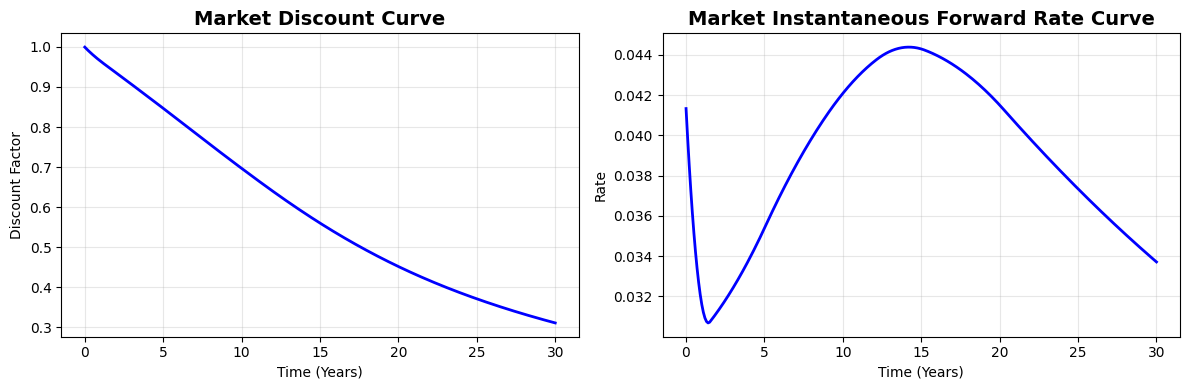

In [2]:
# Discount curve data
file = f'Calibration_Templates\SWPN_Calibration_Template_30092025_{currency}.xlsx'

input_curve = pd.read_excel(file, sheet_name ='Curve')
time = input_curve['Year_Frac']
disc_rate = input_curve['Discount_Factor']
curve = Curve(time, disc_rate)

# Market Curves Plot 
t = np.linspace(0.01, 30, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t, curve.discount(t), 'b-', linewidth=2)
axes[0].set_title('Market Discount Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (Years)', fontsize=10)
axes[0].set_ylabel('Discount Factor', fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].plot(t, curve.inst_forward_rate(t), 'b-', linewidth=2)
axes[1].set_title('Market Instantaneous Forward Rate Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (Years)', fontsize=10)
axes[1].set_ylabel('Rate', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()

### ***2. Swaption Calibration:***

In [3]:
# Calibration 
df = pd.read_excel(file, sheet_name = 'Template')
df['Payment_Dates'] = [[float(x) for x in eval(item)] for item in df['Payment_Dates'].tolist()]

market_prices = {
    'Prices': df['Price'].tolist(),
    'Strike': df['Strike'].tolist(),
    'Notional': df['Notional'].tolist(),
    'Dates': df['Payment_Dates'].tolist()}

# Initialize pricer and calibrator, and calibrate to market
pricer = HullWhitePricer(curve)
calibrator = HullWhiteCalibrator(pricer, market_prices, calibrate_to = 'Swaptions', a_fixed = 0.01)
result = calibrator.calibrate(init_sigma = 0.009)

a fixed: 0.010000, sigma: 0.008623, RMSRE: 2.50361e-02
a fixed: 0.010000, sigma: 0.008579, RMSRE: 2.45063e-02
a fixed: 0.010000, sigma: 0.008579, RMSRE: 2.45063e-02
a fixed: 0.010000, sigma: 0.008579, RMSRE: 2.45062e-02

Calibration successful:
Iterations: 3
Number of instruments: 203
Total Error:  +2.451%

Parameters:
Fixed a: 0.01000
Optimal sigma: 0.00858

Swaption   0:  1.01Y to 9.01 Y | Model:   230.90 | Market:   231.51 | Diff:  -0.263%
Swaption   1:  1.01Y to 8.01 Y | Model:   206.89 | Market:   206.65 | Diff:  +0.115%
Swaption   2:  1.01Y to 7.01 Y | Model:   181.51 | Market:   181.22 | Diff:  +0.162%
Swaption   3:  1.01Y to 10.01Y | Model:   253.38 | Market:   255.08 | Diff:  -0.666%
Swaption   4:  1.01Y to 11.01Y | Model:   274.45 | Market:   277.73 | Diff:  -1.182%
Swaption   5:  1.01Y to 41.01Y | Model:   631.59 | Market:   650.92 | Diff:  -2.971%
Swaption   6:  1.01Y to 36.01Y | Model:   594.91 | Market:   614.16 | Diff:  -3.134%
Swaption   7:  1.01Y to 31.01Y | Model:   5

### ***3. Calibration Results:*** 

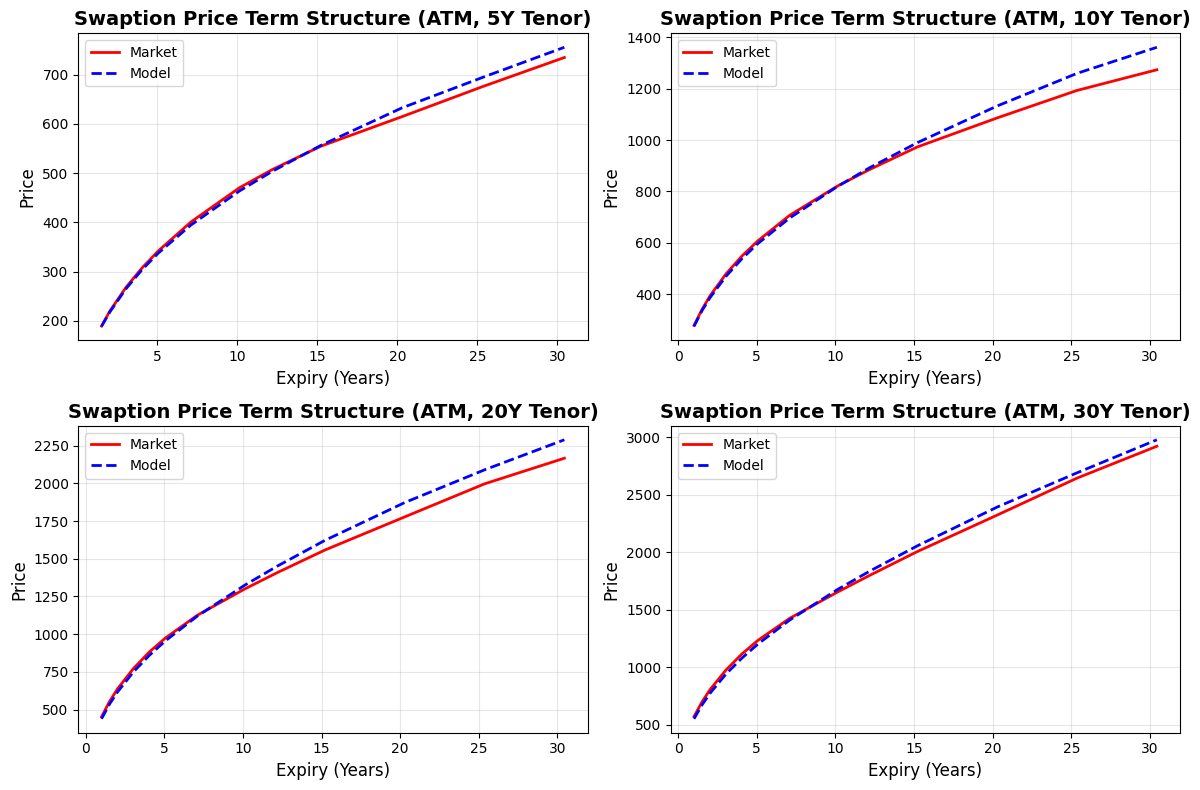

In [4]:
df['Model_Price'] = [pricer.swaption(df['Payment_Dates'][i], df['Notional'][i], df['Strike'][i]/100)/curve.discount(df['Expiry'][i]) for i in range(len(df))]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
Tenors = [5.0, 10.0, 20.0, 30.0]
axes = axes.flatten()

for idx, tenor in enumerate(Tenors):
    df_tenor = df[df['Tenor'] == tenor]
    T_vals = df_tenor['Expiry']
    model_price = df_tenor['Model_Price']
    market_price = df_tenor['Price']

    axes[idx].plot(T_vals, market_price, 'r-', linewidth=2, label='Market')
    axes[idx].plot(T_vals, model_price, 'b--', linewidth=2, label='Model')
    axes[idx].set_title(f'Swaption Price Term Structure (ATM, {int(tenor)}Y Tenor)', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Expiry (Years)', fontsize=12)
    axes[idx].set_ylabel('Price', fontsize=12)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=10)

plt.tight_layout()

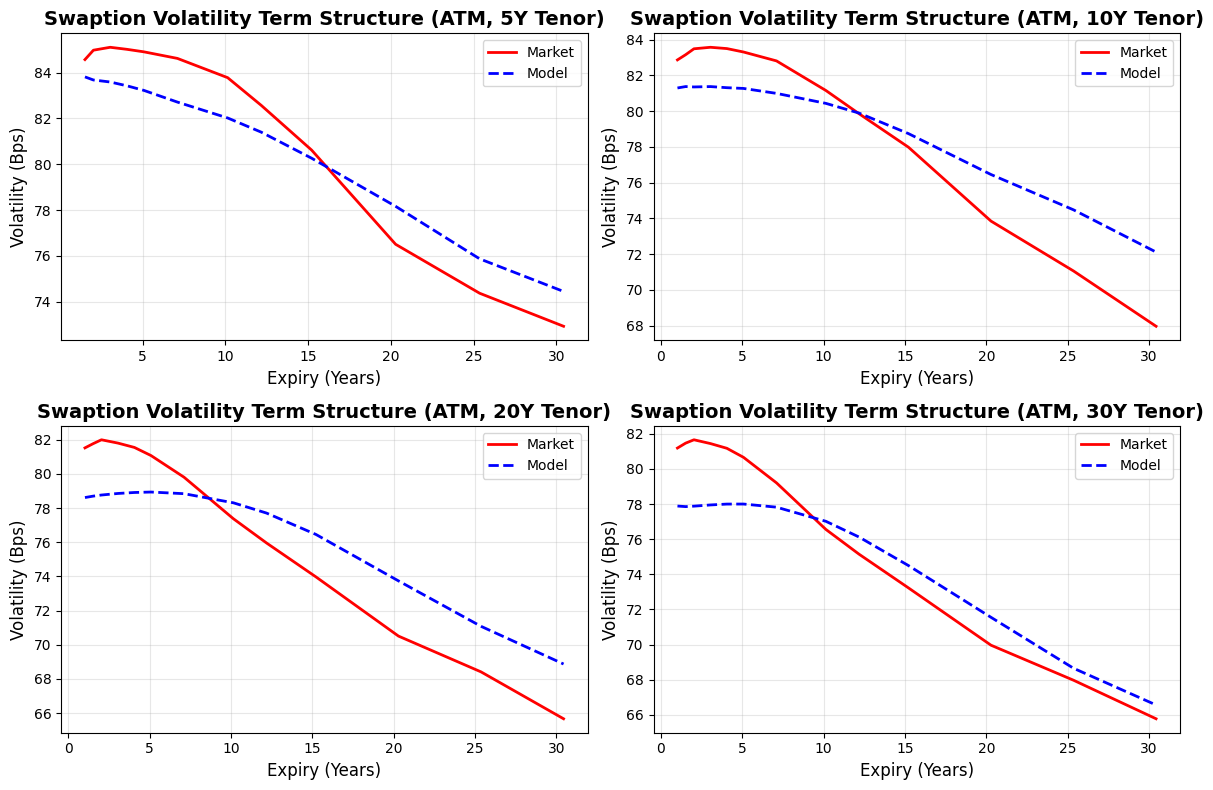

In [5]:
df['Model_Vol (Bps)'] = [black_normal_vol(df['Model_Price'][i], df['Forward'][i], df['Strike'][i], df['Expiry'][i], df['Notional'][i], df['Duration'][i]) for i in range(len(df))]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
Tenors = [5.0, 10.0, 20.0, 30.0]
axes = axes.flatten()

for idx, tenor in enumerate(Tenors):
    df_tenor = df[df['Tenor'] == tenor]
    T_vals = df_tenor['Expiry']
    model_vol = df_tenor['Model_Vol (Bps)']
    market_vol = df_tenor['Volatility (Bps)']

    axes[idx].plot(T_vals, market_vol, 'r-', linewidth=2, label='Market')
    axes[idx].plot(T_vals, model_vol, 'b--', linewidth=2, label='Model')
    axes[idx].set_title(f'Swaption Volatility Term Structure (ATM, {int(tenor)}Y Tenor)', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Expiry (Years)', fontsize=12)
    axes[idx].set_ylabel('Volatility (Bps)', fontsize=12)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=10)

plt.tight_layout()

### ***4. Simulation of Market-Consistent Escenarios:***

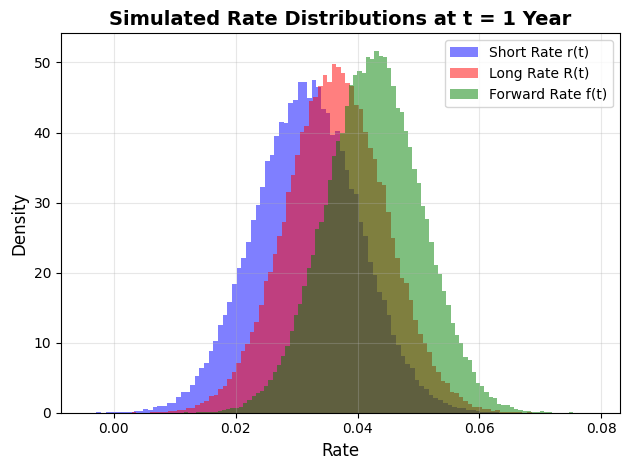

In [6]:
# Simulations
pricer.set_simulation(n_paths = 10**5)
r_t = pricer.curve_sim.short_rate(t = 1) 
R_t = pricer.curve_sim.long_rate(t = 1, T = 10)
f_t = pricer.curve_sim.inst_forward_rate(t = 1, T = 10)

# Plot in the same figure
plt.hist(r_t, bins=100, density=True, alpha=0.5, color='b', label='Short Rate r(t)')
plt.hist(R_t, bins=100, density=True, alpha=0.5, color='r', label='Long Rate R(t)')
plt.hist(f_t, bins=100, density=True, alpha=0.5, color='g', label='Forward Rate f(t)')
plt.title('Simulated Rate Distributions at t = 1 Year', fontsize=14, fontweight='bold')
plt.xlabel('Rate', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

### ***5. Caplets Calibration:***

In [7]:
# Market Prices
file = f'Calibration_Templates\CAP_Calibration_Template_30092025_{currency}.xlsx'
df = pd.read_excel(file, sheet_name ='Template').iloc[1:,:].reset_index(drop=True)

market_prices = {
    'Prices': df['Price'].tolist(),
    'Strike': df['Strike'].tolist(),
    'Notional': df['Notional'].tolist(),
    'Expiry': df['Expiry'].tolist(),
    'Maturity': df['Maturity'].tolist()}

# Initialize pricer and calibrator, and calibrate to market
pricer = HullWhitePricer(curve)
calibrator = HullWhiteCalibrator(pricer, market_prices, calibrate_to='Caplets', a_fixed=0.01)
result = calibrator.calibrate()

a fixed: 0.010000, sigma: 0.009231, RMSRE: 3.39930e-02
a fixed: 0.010000, sigma: 0.008915, RMSRE: 2.59615e-02
a fixed: 0.010000, sigma: 0.009032, RMSRE: 2.36213e-02
a fixed: 0.010000, sigma: 0.009011, RMSRE: 2.35247e-02

Calibration successful:
Iterations: 4
Number of instruments: 50
Total Error:  +2.352%

Parameters:
Fixed a: 0.01000
Optimal sigma: 0.00901

Caplet  0:  1.52Y to 2.02 Y | Model:    23.21 | Market:    23.32 | Diff:  -0.467%
Caplet  1:  2.04Y to 2.54 Y | Model:    27.69 | Market:    27.80 | Diff:  -0.396%
Caplet  2:  3.05Y to 3.55 Y | Model:    24.04 | Market:    24.73 | Diff:  -2.782%
Caplet  3:  3.56Y to 4.06 Y | Model:    27.13 | Market:    27.92 | Diff:  -2.834%
Caplet  4:  4.06Y to 4.56 Y | Model:    30.00 | Market:    30.64 | Diff:  -2.084%
Caplet  5:  4.57Y to 5.07 Y | Model:    32.97 | Market:    33.78 | Diff:  -2.390%
Caplet  6:  5.08Y to 5.58 Y | Model:    36.09 | Market:    36.63 | Diff:  -1.470%
Caplet  7:  6.09Y to 6.59 Y | Model:    31.01 | Market:    32.44 

### ***6. Calibration Results:***

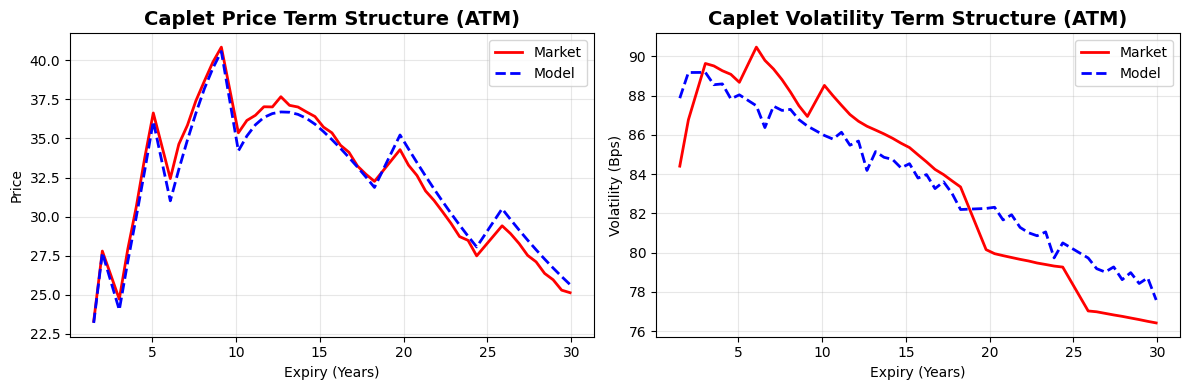

In [8]:
# Plot differences between model and market volatilities
df['Model Price'] = [pricer.caplet(df['Expiry'][i], df['Maturity'][i], df['Notional'][i], df['Strike'][i]/100) for i in range(len(df))]
df['Model Vol'] = [black_normal_vol(df['Model Price'][i], df['Forward'][i], df['Strike'][i], df['Expiry'][i], df['Notional'][i], df['Duration'][i]) for i in range(len(df))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# price plot 
axes[0].plot(df['Expiry'], df['Price'], 'r-', linewidth=2, label='Market')
axes[0].plot(df['Expiry'], df['Model Price'], 'b--', linewidth=2, label='Model')
axes[0].set_title('Caplet Price Term Structure (ATM)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Expiry (Years)', fontsize=10)
axes[0].set_ylabel('Price', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=10)

# Volatility Plot
axes[1].plot(df['Expiry'], df['Volatility (Bps)'], '-r', linewidth=2, label='Market')
axes[1].plot(df['Expiry'], df['Model Vol'], 'b--', linewidth=2, label='Model')
axes[1].set_title('Caplet Volatility Term Structure (ATM)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Expiry (Years)')
axes[1].set_ylabel('Volatility (Bps)')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

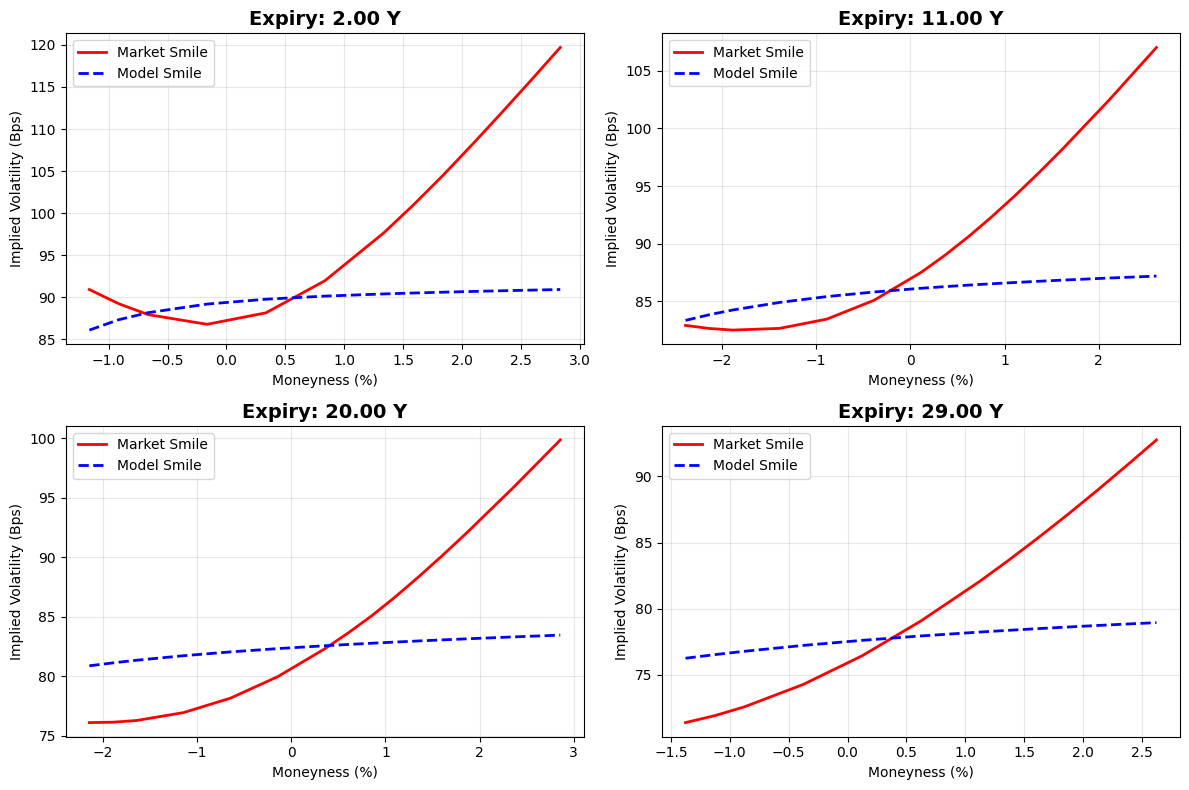

In [9]:
# OTM caplets data
file = f'Calibration_Templates\CAP_Market_Data_30092025_{currency}.xlsx'
df_mkt = pd.read_excel(file)

Moneyness = 3.0; Notional = 10_000; Tenor = 6.0

mask1 = df_mkt['Opt_Type'] == 'Caplet'
mask2 = df_mkt['Tenor']  == Tenor
mask3 = df_mkt['Moneyness'].abs() < Moneyness 

df = df_mkt[mask1 & mask2 & mask3].copy().reset_index(drop=True)
df['Model Price'] = [pricer.caplet(df['Expiry'][i], df['Maturity'][i], Notional, df['Strike'][i]/100) for i in range(len(df))]
df['Model Vol'] = [black_normal_vol(df['Model Price'][i], df['Forward'][i], df['Strike'][i], df['Expiry'][i], Notional, df['Duration'][i]) for i in range(len(df))] 

df_smile = df[['Volatility (Bps)', 'Moneyness', 'Expiry', 'Model Vol']].sort_values(by='Moneyness').dropna().reset_index(drop=True)
expiries = df_smile['Expiry'].sort_values().unique()

# Subplots for various expiries
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axs = axs.flatten()

exp_indices = np.linspace(4, len(expiries) - 1, 4, dtype=int)
for ax, idx in zip(axs, exp_indices):
    expiry = expiries[idx]
    mask = df_smile['Expiry'] == expiry
    ax.plot(df_smile['Moneyness'][mask], df_smile['Volatility (Bps)'][mask], 'r-', linewidth = 2, label='Market Smile')
    ax.plot(df_smile['Moneyness'][mask], df_smile['Model Vol'][mask], 'b--', linewidth = 2, label='Model Smile')
    ax.set_title(f'Expiry: {int(expiry):.2f} Y', fontsize=14, fontweight='bold')
    ax.set_xlabel('Moneyness (%)')
    ax.set_ylabel('Implied Volatility (Bps)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### ***7. Pricing Examples:***

In [ ]:
# Set simulation paths for montcarlo pricing
pricer.set_simulation(n_paths=10**6)

#### **a) Zero-Coupon Bond Options**

In [20]:
# Zero-Coupon Bond Options: Call and Put on a zero-coupon bond
T = 2.0        # Option expiry (years)
S = 10.0       # Bond maturity (years)
K = 0.95       # Strike (bond price)
N = 1_000_000  # Notional

# Pricing with closed-form formula
zcb_call = N * pricer.zero_bond_call(T, S, K, mc=False)
zcb_put = N * pricer.zero_bond_put(T, S, K, mc=False)

# Pricing with Monte Carlo
zcb_call_mc = N * pricer.zero_bond_call(T, S, K, mc=True)
zcb_put_mc = N * pricer.zero_bond_put(T, S, K, mc=True)

print("Zero-Coupon Bond Options (T=2Y, S=10Y, K=0.95)")
print(f"  Call (Analytical): {zcb_call:,.2f}")
print(f"  Call (Monte Carlo): {zcb_call_mc:,.2f}")
print(f"  Put (Analytical):  {zcb_put:,.2f}")
print(f"  Put (Monte Carlo):  {zcb_put_mc:,.2f}")

# Put-call parity verification
P_S = pricer.model.discount_factor(S)
P_T = pricer.model.discount_factor(T)
parity_diff = zcb_call - zcb_put - (P_S - K*P_T)
print(f"\n  Put-Call Parity Check: {parity_diff:.2e} (should be ~0)")

Zero-Coupon Bond Options (T=2Y, S=10Y, K=0.95)
  Call (Analytical): 149.55
  Call (Monte Carlo): 151.99
  Put (Analytical):  192,016.56
  Put (Monte Carlo):  191,939.58

  Put-Call Parity Check: -1.92e+05 (should be ~0)


#### **b) Caplets and Caps**

In [25]:
# Caplet: option on a single forward rate
T1 = 1.0          # Period start (years)
T2 = 1.5          # Period end (years)
N = 1_000_000     # Notional
K = 0.04          # Strike rate (4%)

caplet_price = pricer.caplet(T1, T2, N, K, method='js')
print(f"Caplet Price (T1={T1}Y, T2={T2}Y, K={K*100}%): {caplet_price:,.2f}")


Tau = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]  # Payment dates
K_cap = 0.04

cap_price = pricer.cap(Tau, N, K_cap, mc=False)
floor_price = pricer.floor(Tau, N, K_cap, mc=False)

print(f"\nCap Price (3Y, K={K_cap*100}%): {cap_price:,.2f}")
print(f"Floor Price (3Y, K={K_cap*100}%): {floor_price:,.2f}")

# Verification: Cap - Floor = Payer Swap
swap_payer = pricer.swap(Tau, N, K_cap, payer=True, mc=False)
cap_floor_parity = cap_price - floor_price - swap_payer
print(f"\nCap-Floor Parity Check: {cap_floor_parity:.2e} (should be ~0)")

Caplet Price (T1=1.0Y, T2=1.5Y, K=4.0%): 389.53

Cap Price (3Y, K=4.0%): 3,403.76
Floor Price (3Y, K=4.0%): 22,090.77

Cap-Floor Parity Check: -3.27e-10 (should be ~0)


#### **c) Swaps**

In [29]:
# Swap: exchange of fixed for floating rate
Tau_swap = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]  # Payment dates
N_swap = 10_000_000  # Notional
K_swap = 0.035       # Fixed rate (3.5%)

payer_swap = pricer.swap(Tau_swap, N_swap, K_swap, payer=True, mc=False)
receiver_swap = pricer.swap(Tau_swap, N_swap, K_swap, payer=False, mc=False)

print(f"Payer Swap Value (5Y, K={K_swap*100:.2f}%): {payer_swap:,.2f}")
print(f"Receiver Swap Value (5Y, K={K_swap*100:.2f}%): {receiver_swap:,.2f}")

# Calculate par rate 
annuity = sum((Tau_swap[i] - Tau_swap[i-1]) * pricer.curve.discount(Tau_swap[i]) for i in range(1, len(Tau_swap)))
floating_leg = pricer.curve.discount(Tau_swap[0]) - pricer.curve.discount(Tau_swap[-1])
par_rate = floating_leg / annuity

swap_at_par = pricer.swap(Tau_swap, N_swap, par_rate, payer=True, mc=False)
print(f"\nPar Swap Rate: {par_rate*100:.4f}%")
print(f"Swap Value at Par Rate: {swap_at_par:.2e} (should be ~0)")

Payer Swap Value (5Y, K=3.50%): -50,455.25
Receiver Swap Value (5Y, K=3.50%): 50,455.25

Par Swap Rate: 3.3883%
Swap Value at Par Rate: 0.00e+00 (should be ~0)


#### **d) Swaptions**

In [30]:
# Swaption: option to enter into a swap in the future
Tau_swpn = [1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0]  # Swap starts at T=1Y and lasts 9Y
N_swpn = 5_000_000
K_swpn = 0.04  # Strike rate (4%)

payer_swaption = pricer.swaption(Tau_swpn, N_swpn, K_swpn, payer=True, mc=False)
receiver_swaption = pricer.swaption(Tau_swpn, N_swpn, K_swpn, payer=False, mc=False)

print(f"Payer Swaption (1Yx9Y, K={K_swpn*100}%): {payer_swaption:,.2f}")
print(f"Receiver Swaption (1Yx9Y, K={K_swpn*100}%): {receiver_swaption:,.2f}")

# Swaption with Monte Carlo
payer_swaption_mc = pricer.swaption(Tau_swpn, N_swpn, K_swpn, payer=True, mc=True)
print(f"\nPayer Swaption (Monte Carlo): {payer_swaption_mc:,.2f}")

Payer Swaption (1Yx9Y, K=4.0%): 87,155.18
Receiver Swaption (1Yx9Y, K=4.0%): 188,607.36

Payer Swaption (Monte Carlo): 63,782.69

Payer Swaption (Monte Carlo): 63,782.69


#### **e) Coupon Bonds and Bond Options**

In [14]:
# Coupon bond
Tau_bond = [1.0, 2.0, 3.0, 5.0, 7.0, 10.0]  # Coupon payment dates
C = 0.05      # Annual coupon rate (5%)
N_bond = 100  # Face value

bond_price = pricer.coupon_bond(Tau_bond, C, N_bond)
print(f"Coupon Bond Price (10Y, C={C*100}%): {bond_price:.4f}")

# Floating Rate Note (FRN)
frn_price = pricer.floating_rate_note(Tau_bond, N_bond)
print(f"Floating Rate Note Price (10Y): {frn_price:.4f}")

# Bond option (Jamshidian method)
T_option = 1.0   # Option expiry (years)
K_bond = 95      # Strike (bond price)
Tau_bond_opt = [2.0, 3.0, 5.0, 7.0, 10.0]  # Bond payments (after T)

bond_call = pricer.bond_option(T_option, Tau_bond_opt, C, K_bond, N_bond, call=True, mc=False)
bond_put = pricer.bond_option(T_option, Tau_bond_opt, C, K_bond, N_bond, call=False, mc=False)

print(f"\nBond Call Option (T={T_option}Y, K={K_bond}): {bond_call:.4f}")
print(f"Bond Put Option (T={T_option}Y, K={K_bond}): {bond_put:.4f}")

# Put-call parity verification for bond options
bond_pv = pricer.coupon_bond(Tau_bond_opt, C, N_bond)
P_T_bond = pricer.model.discount_factor(T_option)
bond_parity = bond_call - bond_put - (bond_pv - K_bond * P_T_bond)
print(f"\nBond Option Put-Call Parity Check: {bond_parity:.2e} (should be ~0)")

Coupon Bond Price (10Y, C=5.0%): 300.8576
Floating Rate Note Price (10Y): 42.8912

Bond Call Option (T=1.0Y, K=95): 144.9150
Bond Put Option (T=1.0Y, K=95): 0.0000

Bond Option Put-Call Parity Check: -3.43e-11 (should be ~0)
